## CMSE 201 Final Project
### &#9989; Julia Griese
### &#9989; Section_007
#### &#9989; Due: 4/20/2026

# Investigating the NFL 4th Down

## Background and Motivation

I obtained the NFL Team Stats 2002 - Feb. 2026 (ESPN) dataset through Kaggle. ESPN is a
leading multiplatform sports entertainment network in the US that broadcasts both college
and professional sports, which are enjoyed by many. The network utilizes advanced tracking
technology to collect player metrics and statistics from the NFL. The publicly available
dataset created by an anonymous user contains scraped data from ESPN’s NFL Team Stats Website and contains over 60
variables that describe each matchup over the past 24 seasons. Some of these
variables include date, team matchups, score, first downs, second downs, third downs,
fourth downs, sacks, rushing yards, penalty yards, and many more football statistics. There
are some inefficiencies present in the data, such as missing dates, as well as missing
numbers for red zone conversions and other statistics. These incomplete statistics are all
listed as a “0”, which can affect long-term averages during analysis. Additionally, this
dataset only includes team data and does not include individual player data or notes on
extreme circumstance games. Conveniently, old team names have been replaced with their respective new mascots. City names are not included with team names, so team location changes are unaccounted for. This dataset is very large, which gives us lots of questions to
investigate, but also requires careful and timely manipulation.

Based on my own interest and the features of this dataset, I’ve decided to look exclusively at the 4th downs over time. For clarity, a 4th down is the offensive team's last attempt to try and gain the necessary yards. Failing to do so results in the opposing team getting the football at that mark. This means the offensive team must make a decision to either punt it further away for the opposing team to receive, try to kick a field goal for 3 points, or risk losing the ball by going for the remaining yards. As the game and play styles have changed, have 4th down attempts generally increased or decreased? Additionally, what other teams or factors are correlated with higher 4th down attempts? The 4th down data for home and away teams is consistently recorded and accurate, which makes this analysis more insightful. I am assuming that each attempt comes from a full-time, officiated game. I hope to create visualizations of this data over time using the methods and packages we’ve discussed in class. Additionally, I may create a model that outputs the 4th down history of a given team.


## Methodology

In [82]:
## Loading in necessary packages
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from scipy.optimize import curve_fit

In [83]:
## Loading in data
nfl_data = pd.read_csv('nfl_team_stats_2002-2025.csv') 
nfl_data

,season,week,date,time_et,neutral,away,home,score_away,score_home,first_downs_away,...,redzone_comp_home,redzone_att_home,fumbles_away,fumbles_home,interceptions_away,interceptions_home,def_st_td_away,def_st_td_home,possession_away,possession_home
0,2002,1,2002-09-05,8:30 PM,False,49ers,Giants,16,13,13,...,0,6,0,0,1,3,0,0,27:32,32:28
1,2002,1,2002-09-08,1:00 PM,False,Colts,Jaguars,28,25,18,...,0,8,2,1,0,1,2,0,27:27,32:33
2,2002,1,2002-09-08,1:00 PM,False,Cardinals,Commanders,23,31,14,...,0,8,0,0,1,1,0,0,25:36,34:24
3,2002,1,2002-09-08,1:00 PM,False,Lions,Dolphins,21,49,15,...,0,8,1,0,1,0,0,2,25:36,34:24
4,2002,1,2002-09-08,1:00 PM,False,Eagles,Titans,24,27,17,...,0,7,1,3,2,1,0,0,29:12,30:48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6494,2025,Division,2026-01-18,3:00 PM,False,Texans,Patriots,16,28,16,...,1,1,1,2,4,1,0,1,27:51,32:09
6495,2025,Division,2026-01-18,6:30 PM,False,Rams,Bears,20,17,22,...,2,3,0,0,0,3,0,0,32:26,39:15
6496,2025,Conference,2026-01-25,3:00 PM,False,Patriots,Broncos,10,7,12,...,1,2,0,1,0,1,0,0,33:09,26:51
6497,2025,Conference,2026-01-25,6:30 PM,False,Rams,Seahawks,27,31,26,...,4,5,1,0,0,0,0,0,28:10,31:50


This dataset contains many different statistics, many of which do not relate to my project questions. To increase simplicity and reduce the risk of error, I will create a "cleaned" pandas dataset which uses only the columns I am interested in investigating.

In [84]:
#Re-importing data with our columns of interest
nfl_clean = pd.read_csv('nfl_team_stats_2002-2025.csv', usecols=["season", "away", "home", "drives_away", "drives_home", "fourth_down_comp_away", "fourth_down_att_away", "fourth_down_comp_home", "fourth_down_att_home"]) 

#Utilizing built-in features of the pandas package to view the clean data set and summary statistics
nfl_clean.head()
nfl_clean.describe()

,season,fourth_down_comp_away,fourth_down_att_away,fourth_down_comp_home,fourth_down_att_home,drives_away,drives_home
count,6499.000000,6499.000000,6499.000000,6499.000000,6499.000000,6499.000000,6499.000000
mean,2013.632251,0.567010,1.131559,0.537313,1.045238,12.024158,11.970457
std,6.965278,0.800658,1.160717,0.776868,1.125319,2.523183,2.438354
min,2002.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2008.000000,0.000000,0.000000,0.000000,0.000000,10.000000,10.000000
50%,2014.000000,0.000000,1.000000,0.000000,1.000000,12.000000,12.000000
75%,2020.000000,1.000000,2.000000,1.000000,2.000000,13.000000,13.000000
max,2025.000000,6.000000,8.000000,5.000000,7.000000,26.000000,25.000000


I can get a baseline idea for the values I am investigating using the numpy package and computing capabilities of Python.

In [85]:
print("Average 4th down attempts by home team per game:" , np.mean(nfl_clean['fourth_down_att_home']))
print("Average 4th down attempts by away team per game:" , np.mean(nfl_clean['fourth_down_att_away']))

print("Home 4th down completion %:", (nfl_clean['fourth_down_comp_home'].sum() / nfl_clean['fourth_down_att_home'].sum())*100)
print("Away 4th down completion %:", (nfl_clean['fourth_down_comp_away'].sum() / nfl_clean['fourth_down_att_away'].sum())*100)

Average 4th down attempts by home team per game: 1.0452377288813663
Average 4th down attempts by away team per game: 1.1315587013386674
Home 4th down completion %: 51.40585897247166
Away 4th down completion %: 50.10878433505576


If we want to look at a certain season or team, we can use masking to create a subset of data. Let's compare the most recent 4th down averages and percentages to the baselines we previously computed.

In [86]:
#Creating 2025 season mask
mask_2025 = nfl_clean['season'] == 2025
season_2025 = nfl_clean[mask_2025]

print("2025 Season Average 4th down attempts by home team per game:" , np.mean(season_2025['fourth_down_att_home']))
print("2025 Season Average 4th down attempts by away team per game:" , np.mean(season_2025['fourth_down_att_away']))
print("2025 Home 4th down completion %:",(season_2025['fourth_down_comp_home'].sum() / season_2025['fourth_down_att_home'].sum())*100)
print("2025 Away 4th down completion %:",(season_2025['fourth_down_comp_away'].sum() / season_2025['fourth_down_att_away'].sum())*100)

2025 Season Average 4th down attempts by home team per game: 1.6736842105263159
2025 Season Average 4th down attempts by away team per game: 1.6070175438596492
2025 Home 4th down completion %: 54.926624737945495
2025 Away 4th down completion %: 55.021834061135365


To answer my question of how 4th down attempts have changed over time, I plan to use data visualization to plot season versus total 4th down attempts. I created a line plot using the Seaborn Package.



In [87]:
# Combining home and away fourth down attempts into a single column with totals, dropping NaN values, each row will represent one game
nfl_clean["fourth_down_att_total"] = (nfl_clean["fourth_down_att_home"].fillna(0) + nfl_clean["fourth_down_att_away"].fillna(0))

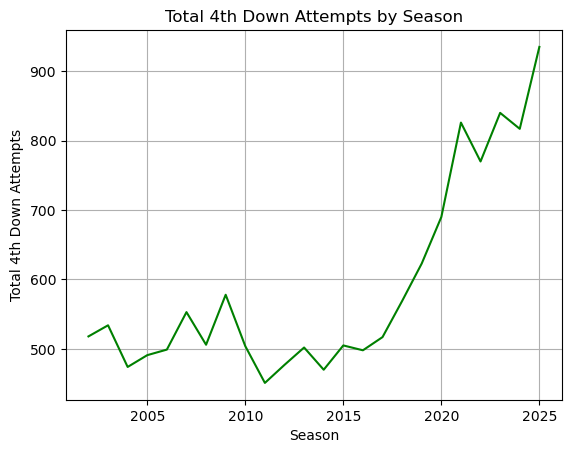

In [88]:
# Grouping total values by season, adds up each row created by the previous code chunk
fourth_down_season_totals = nfl_clean.groupby('season')['fourth_down_att_total'].sum().reset_index()
# Plotting with Seaborn
sns.lineplot(data=fourth_down_season_totals, x='season', y='fourth_down_att_total', color = 'green')
plt.title('Total 4th Down Attempts by Season')
plt.xlabel('Season')
plt.ylabel('Total 4th Down Attempts')
plt.grid()
plt.show()

To figure out a general trend line for this line, I used curve_fit to create a model following y=m*x+b. This line isn't the most tightly-fitting, but it gives us an approximation of the rate of change for total 4th down attempts by season. 

In [89]:
# Assigning variables
x = fourth_down_season_totals['season'].values
y = fourth_down_season_totals['fourth_down_att_total'].values

# Defining linear function
def linear_model(x, m, b):
    return m * x + b

# Fit parameters
params, covariance = curve_fit(linear_model, x, y)

# Results
m, b = params
print("Slope:", m)
print("Intercept:", b)

Slope: 15.435217391303793
Intercept: -30489.351884056847


However, upon further research into the large jump in total attempts, I found that the NFL increased the number of games in the regular season from 16 to 17. This will inflate the total number of attempts, even if game trends aren't actually changing. Since we're treating each game as an opportunity to change gameplay, we must control for this change. I used the mean function from pandas to find the average attempts per game.

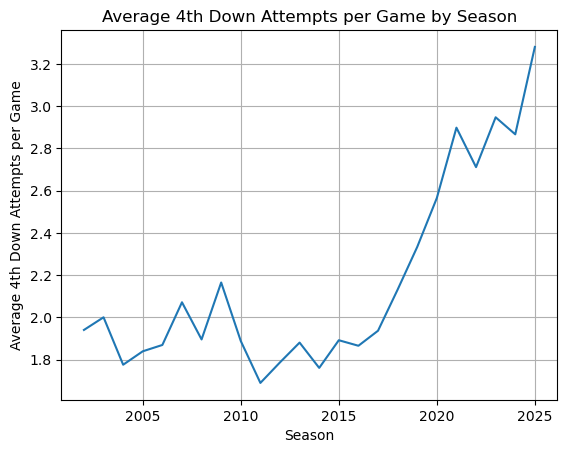

In [90]:
# Finding the average of each season using .mean() from pandas
fourth_down_season_avg = nfl_clean.groupby("season")["fourth_down_att_total"].mean()
fourth_down_season_avg = fourth_down_season_avg.reset_index()
# Plotting results
sns.lineplot(x="season", y="fourth_down_att_total", data=fourth_down_season_avg)
plt.title("Average 4th Down Attempts per Game by Season")
plt.xlabel('Season')
plt.ylabel('Average 4th Down Attempts per Game')
plt.grid()
plt.show()

I created a linear model using the same method I used for total 4th down attempts in the previous section.

In [91]:
# Assigning variables
x = fourth_down_season_avg['season'].values
y = fourth_down_season_avg['fourth_down_att_total'].values

# Defining linear function
def linear_model(x, m, b):
    return m * x + b

# Fit parameters
params, covariance = curve_fit(linear_model, x, y)

# Results
m, b = params
print("Slope:", m)
print("Intercept:", b)

Slope: 0.04953332579392333
Intercept: -97.56932391818556


Looking at my dataset, I realized I could take this analysis another step further by narrowing down opportunities to each drive taken. A drive is the series of plays when the offense has the football until they give it up to the opposing team through a punt, score, or turnover. This plot will allow me to see how often a team goes for the 4th down when able to in this defined "series of plays", which is more insightful than simply looking at the game as a whole. I can use this metric to determine how aggressive teams are on the drive.

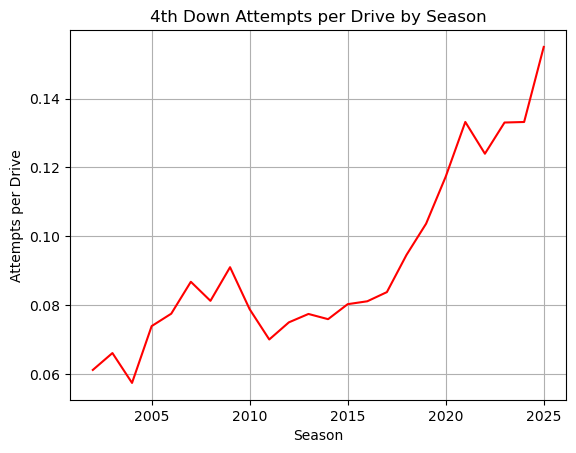

In [92]:
# Adding total_drives column to my cleaned dataset
nfl_clean['total_drives'] = nfl_clean['drives_home'] + nfl_clean['drives_away']

# Taking the sums of fourth down attempts and drives by season and then storing the quotient for plotting
season_fourth_attempts_rate = nfl_clean.groupby('season')[['fourth_down_att_total', 'total_drives']].sum().reset_index()
season_fourth_attempts_rate['fourth_attempts_per_drive'] = (season_fourth_attempts_rate['fourth_down_att_total'] / season_fourth_attempts_rate['total_drives'])

# Plotting results
sns.lineplot(data=season_fourth_attempts_rate, x='season', y='fourth_attempts_per_drive', color = 'red')
plt.title('4th Down Attempts per Drive by Season')
plt.xlabel('Season')
plt.ylabel('Attempts per Drive')
plt.grid()
plt.show()

I created a linear model using the same method I used for total 4th down attempts in the previous section.

In [93]:
# Assigning variables
x = league_avg['season'].values
y = league_avg['attempts_per_drive'].values

# Defining the linear function
def linear_model(x, m, b):
    return m * x + b

# Fit paramters
params, covariance = curve_fit(linear_model, x, y)

# Results
m, b = params
print("Slope:", m)
print("Intercept:", b)

Slope: 0.0032423037845067393
Intercept: -6.436158758088789


Up through this point in my project, I've been using a dataframe with teams designated as either "home" or "away". If I want to look at 4th downs by each team individually, I'll have to pull values from both home and away columns for each team organization. I can do this using Data Wrangling skills.

In [94]:
# Storing home and away stats as separate variables
home = nfl_clean.groupby(['season', 'home'])[['fourth_down_att_home', 'drives_home']].sum()
away = nfl_clean.groupby(['season', 'away'])[['fourth_down_att_away', 'drives_away']].sum()

# Renaming indices so they match
home.index = home.index.set_names(['season', 'team'])
away.index = away.index.set_names(['season', 'team'])

# Renaming columns
home = home.rename(columns={'fourth_down_att_home': 'attempts','drives_home': 'drives'})
away = away.rename(columns={'fourth_down_att_away': 'attempts','drives_away': 'drives'})

# Adding the team's home with the respective away value using the pandas package .add()
team_season = home.add(away, fill_value=0).reset_index()

# Resulting rate
team_season['attempts_per_drive'] = (team_season['attempts'] / team_season['drives'])
team_season

,season,team,attempts,drives,attempts_per_drive
0,2002,49ers,18,270,0.066667
1,2002,Bears,21,276,0.076087
2,2002,Bengals,30,268,0.111940
3,2002,Bills,12,254,0.047244
4,2002,Broncos,23,235,0.097872
...,...,...,...,...,...
763,2025,Seahawks,12,220,0.054545
764,2025,Steelers,26,188,0.138298
765,2025,Texans,21,217,0.096774
766,2025,Titans,35,183,0.191257


To find the specific averages for each season, I created another league average dataset with attempts, drives, and attempts per drive. I then looped through each season and concatenated for the averages.

In [95]:
# Creating data set with league averages
league_avg = (team_season.groupby('season')[['attempts', 'drives']].sum().reset_index())
# Creating attempts per drive column
league_avg['attempts_per_drive'] = (league_avg['attempts'] / league_avg['drives'])
#Looping through each season to find averages by season
att=[]
for i in range(len(league_avg)):
    attempts = league_avg['attempts'][i] / league_avg['drives'][i] 
    att.append(attempts)
    print("The average 4th down attempts per drive in "+ str(league_avg['season'][i]) + " was approximately " + str((attempts)))

The average 4th down attempts per drive in 2002 was approximately 0.061309030654515324
The average 4th down attempts per drive in 2003 was approximately 0.06620381849739648
The average 4th down attempts per drive in 2004 was approximately 0.05754522277528226
The average 4th down attempts per drive in 2005 was approximately 0.07401266204401567
The average 4th down attempts per drive in 2006 was approximately 0.07761704775237206
The average 4th down attempts per drive in 2007 was approximately 0.08686773484134465
The average 4th down attempts per drive in 2008 was approximately 0.08133740556180678
The average 4th down attempts per drive in 2009 was approximately 0.09109535066981876
The average 4th down attempts per drive in 2010 was approximately 0.07891028651949272
The average 4th down attempts per drive in 2011 was approximately 0.07013996889580093
The average 4th down attempts per drive in 2012 was approximately 0.07510628247520075
The average 4th down attempts per drive in 2013 was a

For relevance, I decided to look at the most recent season to see which teams made the most fourth-down attempts with a barplot using Seaborn. I was able to visualize each team's quantity, as well as how each compared to the league average (denoted by the dashed black line).

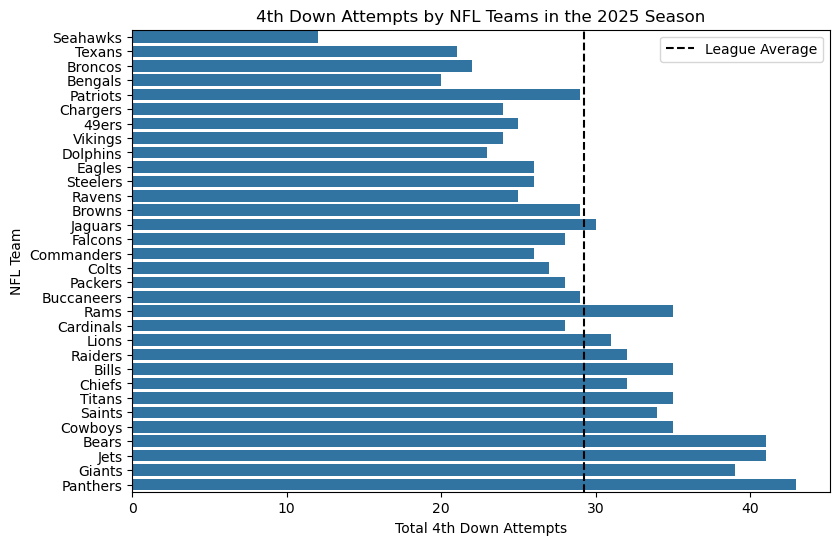

In [96]:
# Reusing mask to pull out 2025 values
teammask_2025 = team_season['season'] == 2025
teams_season_2025 = team_season[teammask_2025].sort_values('attempts_per_drive')
#Plotting attempts by team
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=teams_season_2025, x='attempts', y='team')
plt.title('4th Down Attempts by NFL Teams in the 2025 Season')
plt.xlabel('Total 4th Down Attempts')
plt.ylabel('NFL Team')
ax.axvline(np.mean(teams_season_2025['attempts']), color='black', ls='--', label = 'League Average')
plt.legend()

I can use the 'attempts per drive' metric to determine which teams have historically been more aggressive on the drive. I created the team_avg variable, which takes the mean of each team's "attempts_per_drive" from the past 24 seasons

In [97]:
# Determining which teams make the most attempts per drive
team_avg = (team_season.groupby('team')['attempts_per_drive'].mean().reset_index())
team_avg['rank'] = team_avg['attempts_per_drive'].rank(method='first', ascending=False)
top_teams = team_avg[team_avg['rank'] <= 5]
print(top_teams)

       team  attempts_per_drive  rank
1     Bears            0.102846   4.0
5    Browns            0.110057   2.0
16   Giants            0.102593   5.0
17  Jaguars            0.119557   1.0
19    Lions            0.108287   3.0


For simplicity and insight, I created a function that creates a data visualization when given one or multiple teams. This function will plot a team's attempts per drive by season, as well as the league average over time. The function takes in a list of teams of variable length. If there's a team given that's not in the nfl_data set, the function will output an error message

In [98]:
# Defining function
def plot_fourth_down_team(team_list, team_season = team_season, league_avg = league_avg):
    plt.figure(figsize=(10,6))
    # Looping through teams in the given list
    for team in team_list:
        team_df = team_season[team_season['team'] == team]
    # Setting conditions for input teams NOT in our data
        if team_df.empty:
            print(f"No data for {team}")
            continue
    # Sorting team line(s) by season
        team_df = team_df.sort_values('season')
        sns.lineplot(data=team_df, x='season', y='attempts_per_drive', marker='o', alpha=0.7,label=team)
    # Plotting league average by season
    league_avg_sorted = league_avg.sort_values('season')
    sns.lineplot(data=league_avg_sorted, x='season', y='attempts_per_drive', color='black', linestyle='--', linewidth=3, label='League Avg')
    plt.title('4th Down Attempts per Drive (Multiple Teams)')
    plt.xlabel('Season')
    plt.ylabel('Attempts per Drive')
    # Plot aesthetics
    plt.legend()  
    plt.grid()
    plt.tight_layout()
    plt.show()

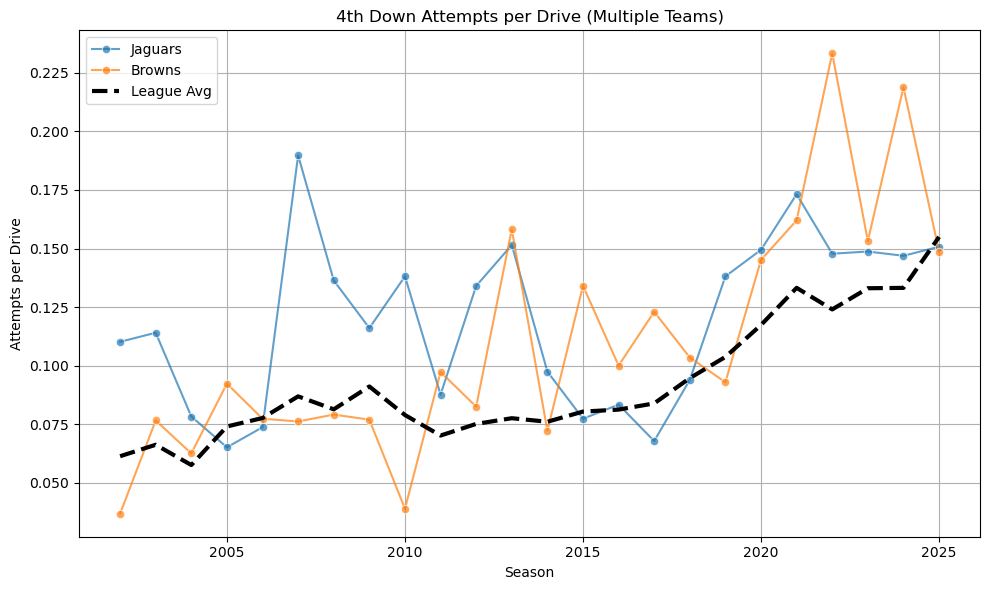

In [99]:
# Plotting the 2 teams
teams1=['Jaguars', 'Browns']
plot_fourth_down_team(teams1)

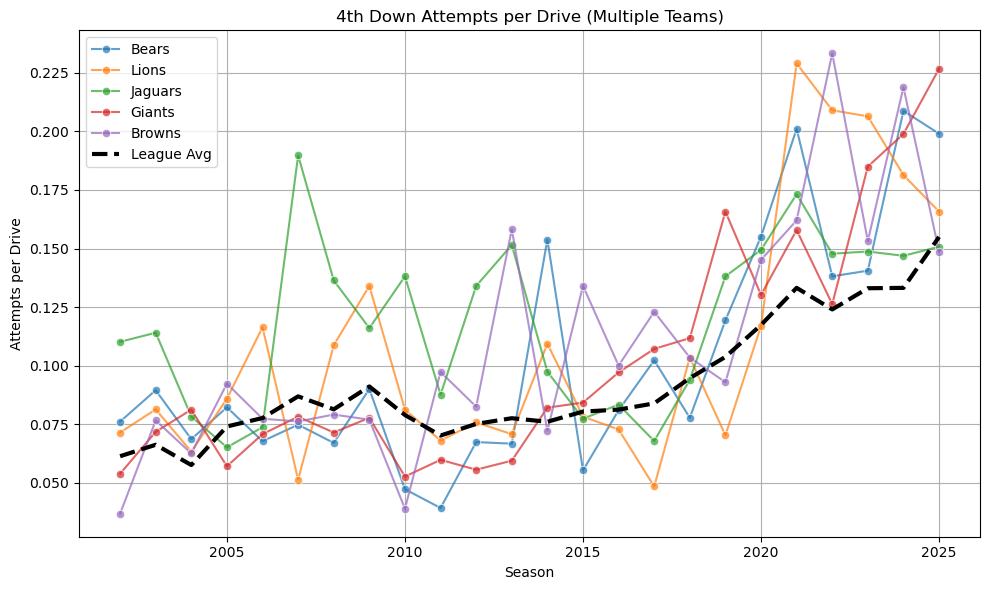

In [100]:
#Plotting our top 5 teams
teams2=['Bears','Lions','Jaguars','Giants','Browns']
plot_fourth_down_team(teams2)


## Results

I can make the generalized statement that the 4th down attempt rate is increasing over time. In attempts to analyze the 4th down most closely, I looked at averages by season, game, and even drive. I found that the average attempts per drive was the most accurate in determining 4th down aggression. My linear model showed that the total 4th down attempts have increased approximately 15.4 on average each season. My linear model for attempts per drive showed a slope of 0.003 additional attempts per drive for each season. Using the attempts per drive as my reference statistic, I found that the Jaguars, Browns, Lions, Bears, and Giants have historically been the top 5 teams in the league when it comes to 4th down aggression. Additional calculations also revealed that 4th down attempts and completion percentage for home and away teams in 2025 are both higher than the average values. 


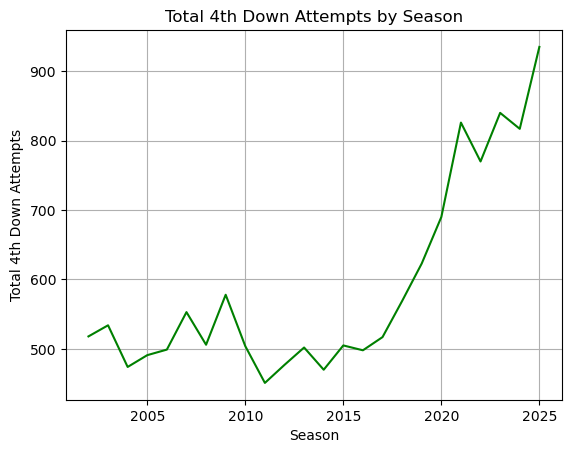

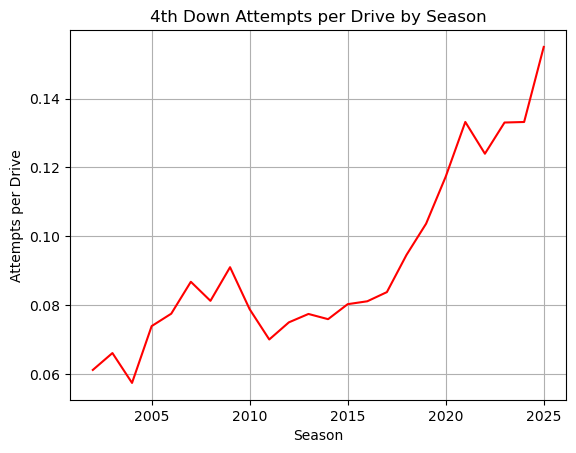

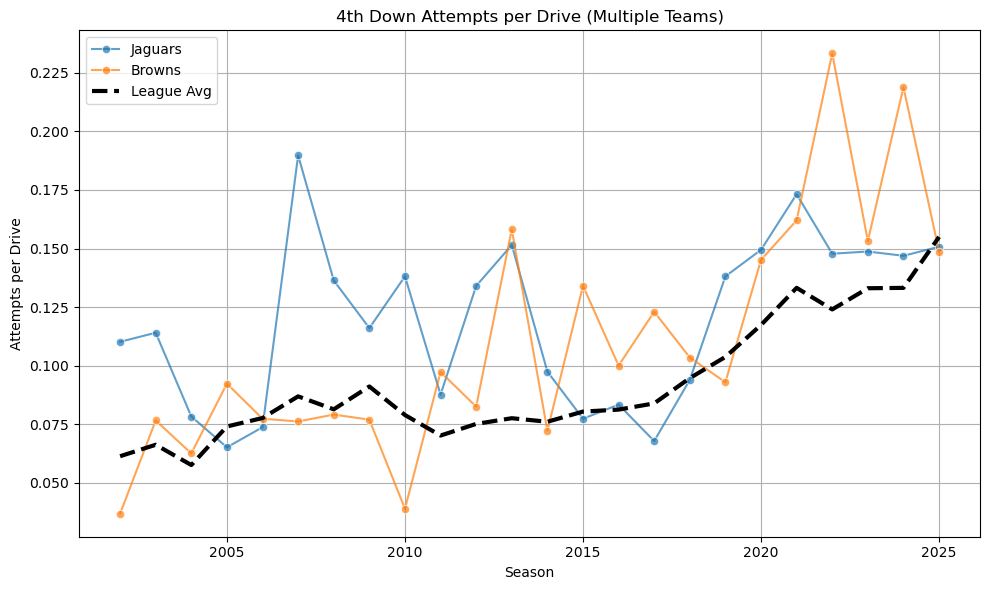

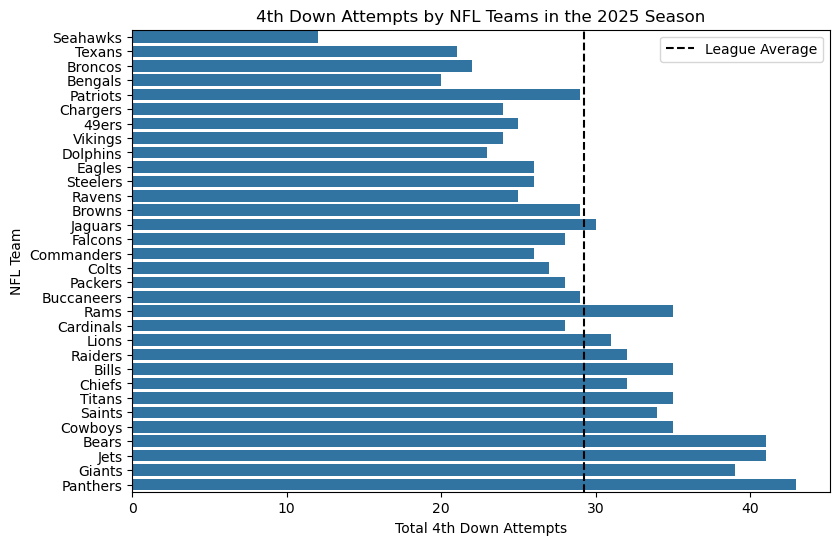

In [101]:
#Average 4th down attempts by home team per game: 1.0452377288813663
#Average 4th down attempts by away team per game: 1.1315587013386674
#Home 4th down completion %: 51.40585897247166
#Away 4th down completion %: 50.10878433505576


#2025 Season Average 4th down attempts by home team per game: 1.6736842105263159
#2025 Season Average 4th down attempts by away team per game: 1.6070175438596492
#2025 Home 4th down completion %: 54.926624737945495
#2025 Away 4th down completion %: 55.021834061135365
sns.lineplot(data=fourth_down_season_totals, x='season', y='fourth_down_att_total', color = 'green')
plt.title('Total 4th Down Attempts by Season')
plt.xlabel('Season')
plt.ylabel('Total 4th Down Attempts')
plt.grid()
plt.show()


sns.lineplot(data=season_fourth_attempts_rate, x='season', y='fourth_attempts_per_drive', color = 'red')
plt.title('4th Down Attempts per Drive by Season')
plt.xlabel('Season')
plt.ylabel('Attempts per Drive')
plt.grid()
plt.show()


plot_fourth_down_team(teams1)

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=teams_season_2025, x='attempts', y='team')
plt.title('4th Down Attempts by NFL Teams in the 2025 Season')
plt.xlabel('Total 4th Down Attempts')
plt.ylabel('NFL Team')
ax.axvline(np.mean(teams_season_2025['attempts']), color='black', ls='--', label = 'League Average')
plt.legend()

## Discussion and Conclusion

I learned that NFL teams have become more aggressive and efficient at attempting the 4th down. However, this conclusion comes with some missing information. To summarize, the total number of 4th down attempts each season is consistently increasing. Additionally, the rate of 4th down attempts per game and the rate of 4th down attempts per drive are both increasing by small amounts each season. My linear model showed that the total 4th down attempts have increased approximately 15.4 on average each season. My linear model for attempts per drive showed a slope of 0.003 additional attempts per drive for each season. Using the attempts per drive as my reference statistic, I found that the Jaguars, Browns, Lions, Bears, and Giants have historically been the top 5 teams in the league when it comes to 4th down aggression. Additional calculations also revealed that 4th down attempts and completion percentage for home and away teams in 2025 are both higher than the average values.

When I initially started this project, I wanted to look at how the probability of going for a 4th down has changed. However, I ran into the obstacle of being unable to quantify "4th down opportunities," which would have helped analyze in-the-moment game decisions. I could have used this data to determine if teams are becoming increasingly likely to attempt the 4th down when given the chance. I also had difficulty accounting for teams that perhaps had a stronger offensive unit. In this case, they may have fewer instances where they reach the 4th down, effectively deflating the ratio of 4th down attempts to total drives. I also had issues with the large size of this dataset and managing its indexes.

Despite the confounding variables I encountered, I still found support for the claim that 4th down attempts are increasing within the game. The linear models I created gave me an idea of how much each rate has changed over the past 24 seasons and my data visualizations illustrated these trends. Although small, these changes contribute to a broader shift that becomes more apparent over longer periods of time. Outside the scope of this class, it would be interesting to conduct deeper statistical testing, such as applying a Poisson model to counts of fourth-down attempts or a Binomial model to analyze conversion success rates. 

Knowing that 4th down attempts are trending upwards, organizations can anticipate these plays before they even happen. In practice, this can look like defending under pressure or analyzing trick 4th down plays. When preparing for an opponent that has historically been more aggressive on the 4th down, having efficient, memorized defensive formations will prevent the opponent from being successful. Above all (in my opinion), these trends simply make football more exciting for the fans watching. Getting to see more of these risky, exciting plays makes for a thrilling football game.

### References

“Horizontal Bar Chart.” Horizontal Bar Chart - Matplotlib 3.10.8 Documentation, 2002–2012 John Hunter, Darren Dale, Eric Firing, Michael Droettboom 
    and the Matplotlib development team; 2012–2025 The Matplotlib development team., matplotlib.org/stable/gallery/lines_bars_and_markers/barh.html. 
    Accessed 20 Apr. 2026. 
“Pandas.Dataframe.Reset_index.” Pandas.DataFrame.Reset_index - Pandas 3.0.2 Documentation, pandas via NumFOCUS, Inc. Hosted by OVHcloud., 2026, 
    pandas.pydata.org/docs/reference/api/pandas.DataFrame.reset_index.html. 
Waskom, Michael. “Seaborn.Barplot.” Seaborn.Barplot - Seaborn 0.13.2 Documentation, 2024, seaborn.pydata.org/generated/seaborn.barplot.html. 

